# Pertemuan 5 — Visualisasi Data

**Nama Lengkap :** Novan Frido Saputro  
**NIM           :** 240401010119  
**Kelas         :** IF403  
**Program Studi :** Informatika  
**Mata Kuliah   :** Data Science  


In [5]:
NAMA      = "Novan Frido Saputro"
NIM       = "240401010119"
PRODI     = "Informatika"
ANGKATAN  = 2024
PERTEMUAN = 5
DATASET   = "Tips"

print("=" * 55)
print("  Pengantar Data Science")
print(f"  Pertemuan {PERTEMUAN} — Visualisasi Data")
print("=" * 55)
print(f"  Nama     : {NAMA}")
print(f"  NIM      : {NIM}")
print(f"  Dataset  : {DATASET}")
print("=" * 55)

  Pengantar Data Science
  Pertemuan 5 — Visualisasi Data
  Nama     : Novan Frido Saputro
  NIM      : 240401010119
  Dataset  : Tips


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Load dataset Tips (built-in seaborn, tidak perlu upload)
df = sns.load_dataset('tips')

print("✅ Library diimport & dataset dimuat!")
print(f"\n📊 Shape     : {df.shape[0]} baris × {df.shape[1]} kolom")
print(f"Kolom       : {list(df.columns)}")
print(f"\n--- 5 Baris Pertama ---")
print(df.head())
print(f"\n--- Statistik Deskriptif ---")
print(df.describe().round(2))
print(f"\n--- Info Kolom ---")
print(df.dtypes)

✅ Library diimport & dataset dimuat!

📊 Shape     : 244 baris × 7 kolom
Kolom       : ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']

--- 5 Baris Pertama ---
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

--- Statistik Deskriptif ---
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00

--- Info Kolom ---
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size     

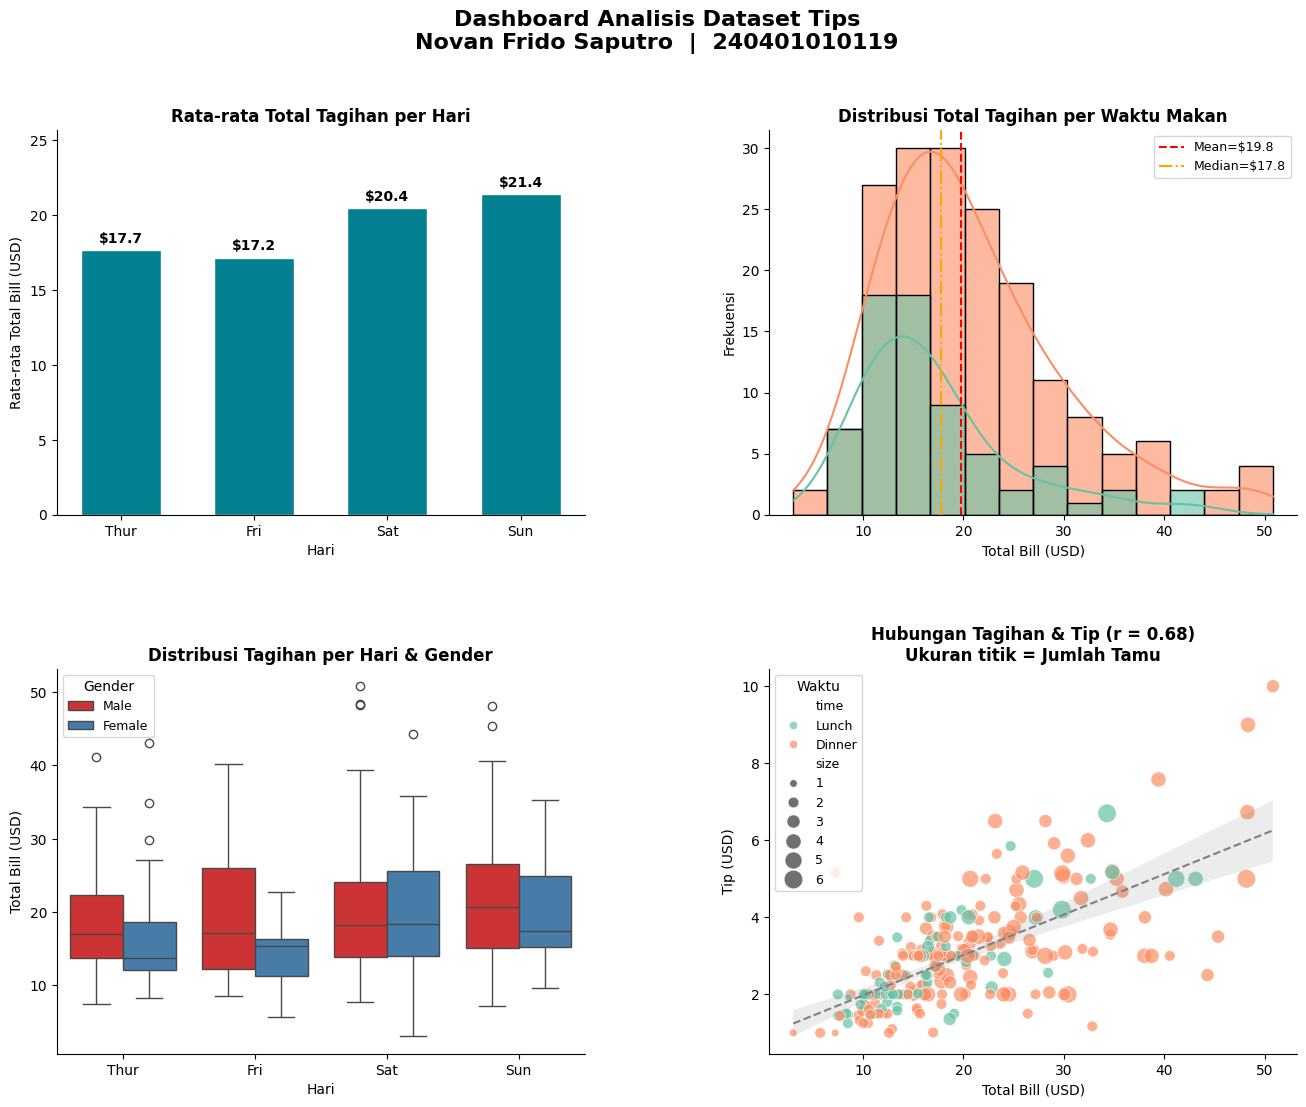

✅ Dashboard disimpan: dashboard_tips.png


In [7]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle(
    f'Dashboard Analisis Dataset Tips\n{NAMA}  |  {NIM}',
    fontsize=16, fontweight='bold', y=0.98
)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])   # kiri atas
ax2 = fig.add_subplot(gs[0, 1])   # kanan atas
ax3 = fig.add_subplot(gs[1, 0])   # kiri bawah
ax4 = fig.add_subplot(gs[1, 1])   # kanan bawah


# ------------------------------------------------------------------
# GRAFIK 1: Bar Chart — Rata-rata Total Tagihan per Hari
# Menjawab: Hari mana yang menghasilkan tagihan tertinggi?
# ------------------------------------------------------------------
urutan_hari = ['Thur', 'Fri', 'Sat', 'Sun']
avg_by_day  = df.groupby('day')['total_bill'].mean().reindex(urutan_hari)

bars = ax1.bar(avg_by_day.index, avg_by_day.values,
               color='#028090', edgecolor='white', width=0.6)

# Tambahkan label nilai di atas tiap bar
for bar, val in zip(bars, avg_by_day.values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'${val:.1f}', ha='center', va='bottom',
             fontsize=10, fontweight='bold')

ax1.set_title('Rata-rata Total Tagihan per Hari', fontsize=12, fontweight='bold')
ax1.set_xlabel('Hari')
ax1.set_ylabel('Rata-rata Total Bill (USD)')
ax1.set_ylim(0, avg_by_day.max() * 1.2)
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top', 'right']].set_visible(False)


# ------------------------------------------------------------------
# GRAFIK 2: Histogram + KDE — Distribusi Tagihan per Waktu Makan
# Menjawab: Bagaimana sebaran nilai tagihan di Lunch vs Dinner?
# ------------------------------------------------------------------
sns.histplot(data=df, x='total_bill', hue='time',
             kde=True, palette='Set2', alpha=0.6, ax=ax2)

ax2.axvline(df['total_bill'].mean(), color='red', linestyle='--',
            linewidth=1.5, label=f"Mean=${df['total_bill'].mean():.1f}")
ax2.axvline(df['total_bill'].median(), color='orange', linestyle='-.',
            linewidth=1.5, label=f"Median=${df['total_bill'].median():.1f}")

ax2.set_title('Distribusi Total Tagihan per Waktu Makan', fontsize=12, fontweight='bold')
ax2.set_xlabel('Total Bill (USD)')
ax2.set_ylabel('Frekuensi')
ax2.legend(fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)


# ------------------------------------------------------------------
# GRAFIK 3: Boxplot — Distribusi Tagihan per Hari & Gender
# Menjawab: Apakah ada perbedaan pola tagihan antara pria & wanita?
# ------------------------------------------------------------------
sns.boxplot(data=df, x='day', y='total_bill',
            hue='sex', palette='Set1',
            order=urutan_hari, ax=ax3)

ax3.set_title('Distribusi Tagihan per Hari & Gender', fontsize=12, fontweight='bold')
ax3.set_xlabel('Hari')
ax3.set_ylabel('Total Bill (USD)')
ax3.legend(title='Gender', fontsize=9)
ax3.spines[['top', 'right']].set_visible(False)


# ------------------------------------------------------------------
# GRAFIK 4: Scatter Plot — Hubungan Tagihan vs Tip
# Menjawab: Apakah tagihan lebih besar menghasilkan tip lebih besar?
# ------------------------------------------------------------------
sns.scatterplot(data=df, x='total_bill', y='tip',
                hue='time', size='size',
                sizes=(30, 180), palette='Set2',
                alpha=0.7, ax=ax4)
sns.regplot(data=df, x='total_bill', y='tip',
            scatter=False, color='gray',
            line_kws={'linewidth': 1.5, 'linestyle': '--'},
            ax=ax4)

# Hitung korelasi Pearson
from scipy import stats
r, p = stats.pearsonr(df['total_bill'], df['tip'])

ax4.set_title(f'Hubungan Tagihan & Tip (r = {r:.2f})\nUkuran titik = Jumlah Tamu',
              fontsize=12, fontweight='bold')
ax4.set_xlabel('Total Bill (USD)')
ax4.set_ylabel('Tip (USD)')
ax4.legend(title='Waktu', fontsize=9)
ax4.spines[['top', 'right']].set_visible(False)


# Simpan dashboard
plt.savefig('dashboard_tips.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard disimpan: dashboard_tips.png")

## Narasi Dashboard — Dataset Tips

---

### Grafik 1: Rata-rata Total Tagihan per Hari (Bar Chart)

**What?**
Sabtu dan Minggu memiliki rata-rata tagihan tertinggi (sekitar $20–21),
sementara Kamis dan Jumat menghasilkan tagihan yang lebih rendah (~$17–18).

**So what?**
Weekend menghasilkan pendapatan lebih tinggi, kemungkinan karena
pelanggan datang dalam kelompok lebih besar dan memesan lebih banyak.

**Now what?**
Perlu dieksplorasi apakah jumlah tamu (size) lebih besar di weekend
dibanding weekday, dan apakah perlu penambahan staf di akhir pekan.

---

### Grafik 2: Distribusi Total Tagihan per Waktu Makan (Histogram + KDE)

**What?**
Distribusi total tagihan bersifat right-skewed (mean > median),
dengan mayoritas tagihan berada di rentang $10–25.
Dinner cenderung memiliki tagihan lebih tinggi dibanding Lunch.

**So what?**
Adanya right-skew menunjukkan ada sejumlah kecil meja dengan tagihan
sangat tinggi yang menarik nilai rata-rata ke atas.

**Now what?**
Perlu diteliti siapa pelanggan dengan tagihan >$40 — apakah meja besar
atau pelanggan yang memesan menu premium tertentu.

---

### Grafik 3: Distribusi Tagihan per Hari & Gender (Boxplot)

**What?**
Pria (Male) secara konsisten memiliki median tagihan yang sedikit lebih
tinggi dari wanita di semua hari. Sabtu memiliki sebaran (IQR) paling
lebar, menandakan variasi tagihan paling tinggi.

**So what?**
Perbedaan tagihan antar gender mungkin mencerminkan perbedaan perilaku
pemesanan, bukan sekadar perbedaan jumlah orang.

**Now what?**
Analisis lanjutan dapat meneliti apakah perbedaan ini signifikan secara
statistik menggunakan uji Mann-Whitney atau t-test.

---

### Grafik 4: Hubungan Tagihan vs Tip (Scatter Plot)

**What?**
Terdapat korelasi positif sedang antara total tagihan dan jumlah tip
(r ≈ 0.68). Semakin besar tagihan, tip cenderung lebih besar.
Ukuran titik (jumlah tamu) tidak menunjukkan pola yang jelas terhadap tip.

**So what?**
Korelasi r = 0.68 menunjukkan hubungan yang cukup kuat namun tidak
sempurna — ada pelanggan yang memberi tip besar meski tagihannya kecil.

**Now what?**
Perlu diteliti faktor lain yang mempengaruhi tip selain tagihan,
seperti waktu makan, hari, atau apakah ada perokok di meja.
"""


## Kesimpulan — Pertemuan 5: Visualisasi Data

Pertemuan ini mengubah cara pandang saya tentang grafik. Selama ini saya pikir visualisasi hanya soal membuat tampilan yang menarik, tapi ternyata ada pertanyaan analitik di balik setiap pilihan jenis grafik — dan pendekatan "What? So what? Now what?" membantu saya untuk tidak berhenti hanya di level "melihat" grafik.

Dari dataset Tips, beberapa pola menarik yang saya temukan: Sabtu dan Minggu adalah hari dengan tagihan tertinggi, dan ada korelasi positif yang cukup kuat antara total tagihan dengan tip. Tapi yang lebih menarik adalah distribusi tagihan yang tidak simetris — ada beberapa meja dengan tagihan sangat tinggi yang membuat rata-rata terlihat lebih besar dari kondisi tipikal. Ini menunjukkan pentingnya tidak hanya bergantung pada mean.

Secara teknis, saya juga belajar cara membuat layout multi-plot yang rapi dalam satu figure. Ini akan sangat berguna untuk membuat laporan atau dashboard analisis ke depannya.
